## 0. Imports and Configurations

In [48]:
import os
from dotenv import load_dotenv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor

load_dotenv()

USE_S3 = os.getenv("USE_S3", "false").lower() == "true"

## Load Cleaned Dataset

In [49]:
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, '..', 'data')

# Dynamic route to the data file
if USE_S3:
    df = pd.read_csv(f"s3://{os.getenv('S3_BUCKET')}/cleaned_data.csv")
else:
    df = pd.read_csv(os.path.join(DATA_DIR, 'cleaned_data.csv'))

print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)

BASE_DIR: /home/admin/Documents/nextbuy/notebooks
DATA_DIR: /home/admin/Documents/nextbuy/notebooks/../data


## Define target

In [50]:
basket_size = df.groupby('order_id').size().reset_index(name='basket_size')
print(basket_size.head())

   order_id  basket_size
0         2            9
1         4           13
2         6            3
3         8            1
4        21            5


## Orders dataset

In [51]:
orders = df.groupby('order_id').first().reset_index()

orders = orders.merge(basket_size, on='order_id')

## Feature engineering

In [52]:
# Features basées sur l'historique PASSÉ du user (pas de leakage)
orders = orders.sort_values(['user_id', 'order_number'])

# Moyenne des tailles de panier des commandes précédentes
orders['user_avg_basket'] = (
    orders.groupby('user_id')['basket_size']
    .transform(lambda x: x.shift(1).expanding().mean())
)

orders['user_avg_basket3'] = (
    orders.groupby('user_id')['basket_size']
    .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
)

# Vaiablilté
orders['user_std_basket'] = (
    orders.groupby('user_id')['basket_size']
    .transform(lambda x:x.shift(1).expanding().std())
)

# Taille du dernier panier
orders['user_last_basket'] = (
    orders.groupby('user_id')['basket_size']
    .transform(lambda x: x.shift(1))
)

# Nombre de commandes passées
orders['user_n_orders_so_far'] = orders.groupby('user_id').cumcount()

# Supprimer les 1ères commandes (pas d'historique dispo)
orders = orders.dropna(subset=['user_avg_basket']).copy()

print(orders[['order_id', 'basket_size', 'user_avg_basket', 'user_last_basket', 'user_n_orders_so_far']].head(10))


        order_id  basket_size  user_avg_basket  user_last_basket  \
191911    473747            5         6.000000               6.0   
741367   2398795            6         5.500000               5.0   
154747    431534            8         5.666667               6.0   
614637   2254736            5         6.250000               8.0   
874865   2550362            9         6.000000               5.0   
423331   2037211            5        11.000000              11.0   
166020    444309            9         8.000000               5.0   
282073    676467            6         8.333333               9.0   
417326   2030307            2         7.000000               7.0   
881364   2557754            3         4.500000               2.0   

        user_n_orders_so_far  
191911                     1  
741367                     2  
154747                     3  
614637                     4  
874865                     5  
423331                     1  
166020                     2  
282

## Feature preparation

In [53]:
features = [
    # variables temporelles
    "order_dow",
    "order_hour_of_day",
    # "days_since_prior_order",

    # historique client
    "order_number",
    # "is_first_order",

    # historique panier passé safe
    "user_avg_basket",       # moyenne des paniers précédents
    "user_avg_basket3",      # moyenne des 3 derniers paniers
    "user_std_basket",       # écart-type des paniers précédents
    "user_last_basket",      # taille du dernier panier
    "user_n_orders_so_far",  # nombre de commandes passées
]

target = "basket_size"

df_model = orders[features + [target]].dropna()
print(df_model.shape)


(921969, 9)


## Train test split

In [54]:
X = df_model[features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Taille de l'ensemble d'entraînement :", X_train.shape)
print("Taille de l'ensemble de test :", X_test.shape)

Taille de l'ensemble d'entraînement : (737575, 8)
Taille de l'ensemble de test : (184394, 8)


## Baseline

In [55]:
model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(rmse, mae, r2)

5.609258406684417 4.018312699980845 0.43774536295972166


## Random Forest

In [56]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

pred = rf.predict(X_test)

## Evaluation

In [57]:
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(rmse, mae, r2)

5.4923758694654925 3.9249640469938307 0.4609331176634791


## Feature importance

[0.00405724 0.04693462 0.0027837  0.91069419 0.00734312 0.00914089
 0.00552912 0.01351712]


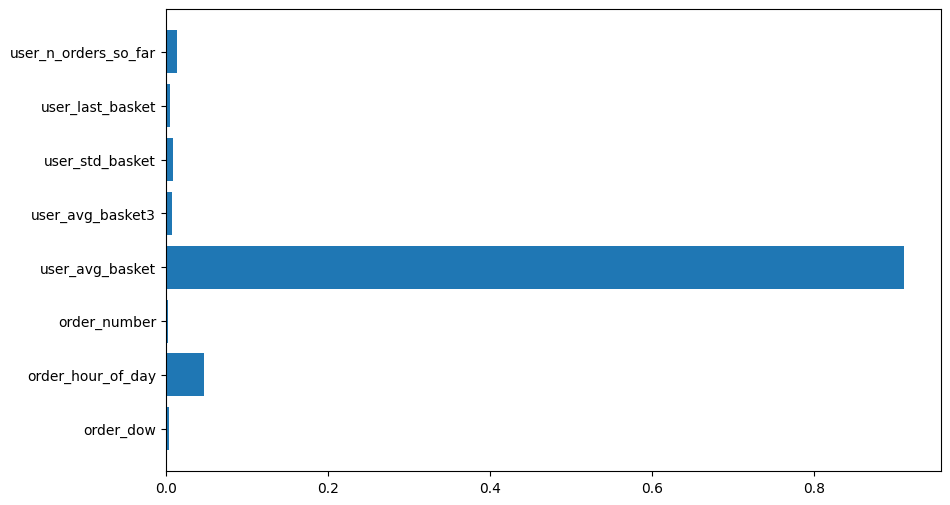

In [58]:
importances = rf.feature_importances_
print(importances)

plt.figure(figsize=(10,6))
plt.barh(range(len(features)), importances)
plt.yticks(range(len(features)), features)
plt.show()